In [ ]:
# Import the required libraries
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
# Read .csv files
customers = pd.read_csv("/content/retail_sales/customers.csv")
orders = pd.read_csv("/content/retail_sales/orders.csv")
products = pd.read_csv("/content/retail_sales/products.csv")

In [ ]:
# Join all the datasets together using inner join
merged_df = pd.merge(customers, orders, on='customer_id', how='inner')
merged_df = pd.merge(merged_df, products, on='product_id', how='inner')
merged_df.head()

,customer_id,gender,age,city,signup_date,loyalty_member,order_id,product_id,order_date,quantity,payment_method,product_name,category,price
0,C0001,Male,19,Liverpool,2023-10-17,Yes,O00758,P032,2024-05-15,3,Card,Keyboard 32,Home,199.76
1,C0001,Male,19,Liverpool,2023-10-17,Yes,O01432,P042,2024-03-23,1,Card,Smart Watch 42,Clothing,285.64
2,C0001,Male,19,Liverpool,2023-10-17,Yes,O02074,P004,2023-02-24,5,Card,Smart Watch 4,Home,220.82
3,C0001,Male,19,Liverpool,2023-10-17,Yes,O02462,P055,2023-05-23,3,Cash,Monitor 55,Sports,41.44
4,C0001,Male,19,Liverpool,2023-10-17,Yes,O02934,P065,2023-03-06,5,Card,USB Cable 65,Beauty,75.50


In [ ]:
# Mengetahui distribusi tanggal terawal dan terakhir
earliest_date = merged_df['order_date'].min()
latest_date = merged_df['order_date'].max()

print("Tanggal terlama:", earliest_date)
print("Tanggal terbaru:", latest_date)

Tanggal terlama: 2023-01-01
Tanggal terbaru: 2024-05-15


In [ ]:
# Find total of rows and columns
merged_df.shape

(4000, 14)

In [ ]:
# Find the dataframe's info
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     4000 non-null   object 
 1   gender          4000 non-null   object 
 2   age             4000 non-null   int64  
 3   city            4000 non-null   object 
 4   signup_date     4000 non-null   object 
 5   loyalty_member  4000 non-null   object 
 6   order_id        4000 non-null   object 
 7   product_id      4000 non-null   object 
 8   order_date      4000 non-null   object 
 9   quantity        4000 non-null   int64  
 10  payment_method  4000 non-null   object 
 11  product_name    4000 non-null   object 
 12  category        4000 non-null   object 
 13  price           4000 non-null   float64
dtypes: float64(1), int64(2), object(11)
memory usage: 437.6+ KB


In [ ]:
# Spot missing values
missing_values = merged_df.isnull().sum()
missing_values

,0
customer_id,0
gender,0
age,0
city,0
signup_date,0
loyalty_member,0
order_id,0
product_id,0
order_date,0
quantity,0


In [ ]:
# Check if there are duplicate values
duplicates = merged_df.duplicated().sum()
duplicates

np.int64(0)

In [ ]:
# Describe the data
merged_df.describe()

,age,quantity,price
count,4000.000000,4000.000000,4000.000000
mean,41.535000,2.974750,139.516300
std,13.627113,1.411599,86.734028
min,18.000000,1.000000,11.070000
25%,30.000000,2.000000,59.030000
50%,41.000000,3.000000,120.140000
75%,53.000000,4.000000,213.020000
max,65.000000,5.000000,289.840000


In [ ]:
# Define age bins and labels
bins = [18, 25, 32, 40, 50, 60, 70]
labels = ['18-25', '26-32', '33-40', '41-50', '51-60', '61+']

# Create a new 'age_group' column based on the defined bins
merged_df['age_group'] = pd.cut(merged_df['age'], bins=bins, labels=labels, right=False)

# Display the first few rows with the new 'age_group' column
display(merged_df.head())

,customer_id,gender,age,city,signup_date,loyalty_member,order_id,product_id,order_date,quantity,payment_method,product_name,category,price,age_group
0,C0001,Male,19,Liverpool,2023-10-17,Yes,O00758,P032,2024-05-15,3,Card,Keyboard 32,Home,199.76,18-25
1,C0001,Male,19,Liverpool,2023-10-17,Yes,O01432,P042,2024-03-23,1,Card,Smart Watch 42,Clothing,285.64,18-25
2,C0001,Male,19,Liverpool,2023-10-17,Yes,O02074,P004,2023-02-24,5,Card,Smart Watch 4,Home,220.82,18-25
3,C0001,Male,19,Liverpool,2023-10-17,Yes,O02462,P055,2023-05-23,3,Cash,Monitor 55,Sports,41.44,18-25
4,C0001,Male,19,Liverpool,2023-10-17,Yes,O02934,P065,2023-03-06,5,Card,USB Cable 65,Beauty,75.50,18-25


In [ ]:
# Calculate the count of 'Male' and 'Female' for each age group
gender_age_group_counts = merged_df.groupby(['age_group', 'gender']).size().unstack(fill_value=0)

# Prepare data for pyramid plot: make male counts negative for left side of the plot
gender_age_group_counts['Male'] = -gender_age_group_counts['Male']

# Ensure the index (age_group) is in the desired order for plotting
gender_age_group_counts = gender_age_group_counts.reindex(labels)

display(gender_age_group_counts)

/tmp/ipykernel_946/1471885278.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gender_age_group_counts = merged_df.groupby(['age_group', 'gender']).size().unstack(fill_value=0)


gender,Female,Male
age_group,,
18-25,295,-281
26-32,273,-277
33-40,312,-385
41-50,471,-407
51-60,362,-467
61+,219,-251


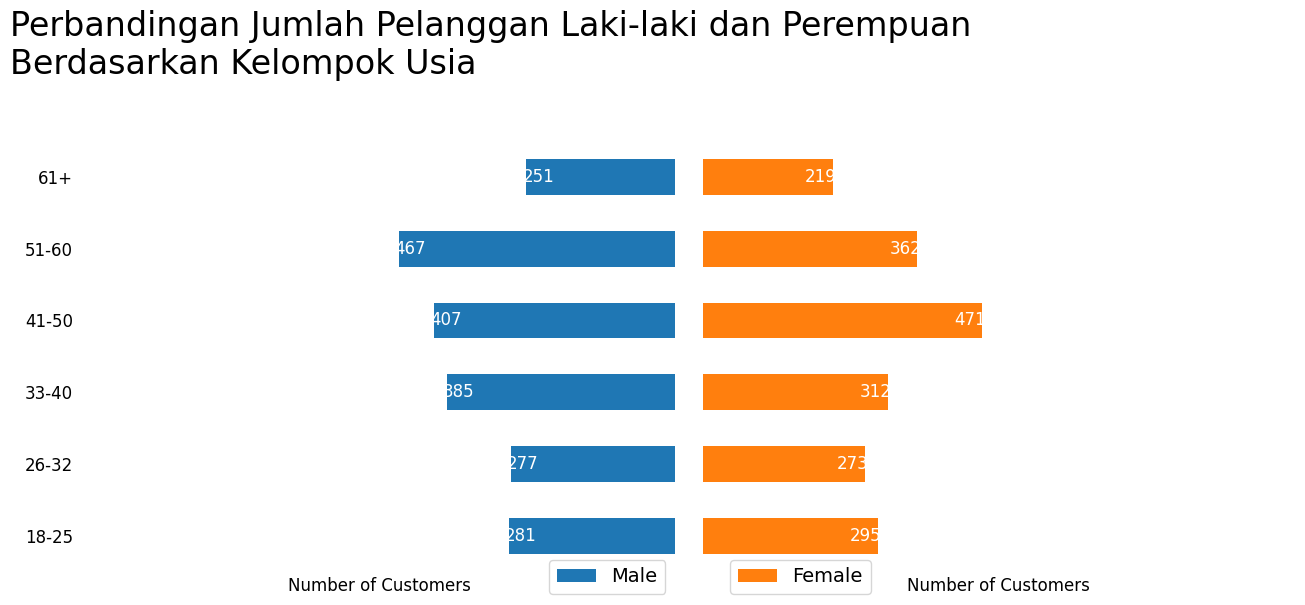

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

fig.suptitle("Perbandingan Jumlah Pelanggan Laki-laki dan Perempuan\nBerdasarkan Kelompok Usia",
             x=0., y=1.0, fontsize=24, ha="left")

# Plotting Male counts
gender_age_group_counts["Male"].plot(kind="barh", ax=axes[0], color="tab:blue", xlim=[-1000, 0])
axes[0].set_ylabel("")
axes[0].set_yticklabels(gender_age_group_counts.index, fontsize=12)
axes[0].tick_params(left=False, bottom=False, labelbottom=False)
axes[0].set_xlabel("Number of Customers", fontsize=12)
axes[0].legend(["Male"], fontsize=14, bbox_to_anchor=(0., 0., 1., .05))
axes[0].set_frame_on(False)

# Plotting Female counts
gender_age_group_counts["Female"].plot(kind="barh", ax=axes[1], color="tab:orange", xlim=[0, 1000])
axes[1].set_ylabel("")
axes[1].set_yticklabels([]) # Hide y-axis labels as they are on the left side
axes[1].tick_params(left=False, bottom=False, labelbottom=False)
axes[1].set_xlabel("Number of Customers", fontsize=12)
axes[1].legend(["Female"], fontsize=14, bbox_to_anchor=(0., 0., 0.3, .05))
axes[1].set_frame_on(False)

# Annotate bars
for i, (male_count, female_count) in enumerate(zip(gender_age_group_counts["Male"], gender_age_group_counts["Female"])):
    axes[0].annotate(str(abs(int(male_count))), (male_count + 20, i), color="w", va="center", ha="center", fontsize=12)
    axes[1].annotate(str(int(female_count)), (female_count - 20, i), color="w", va="center", ha="center", fontsize=12)

plt.tight_layout(rect=(0,0,1,0.95))
plt.show()

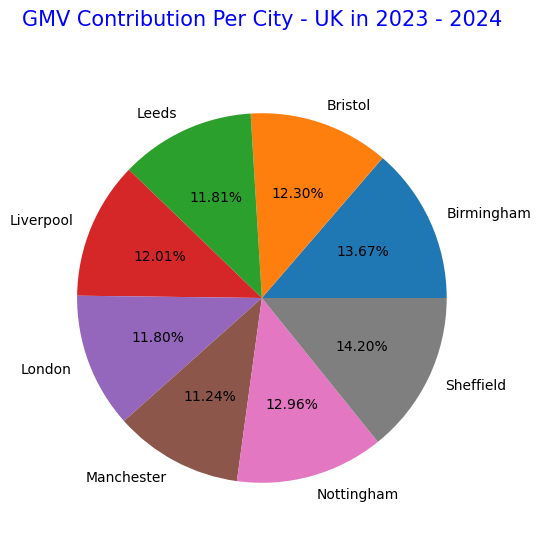

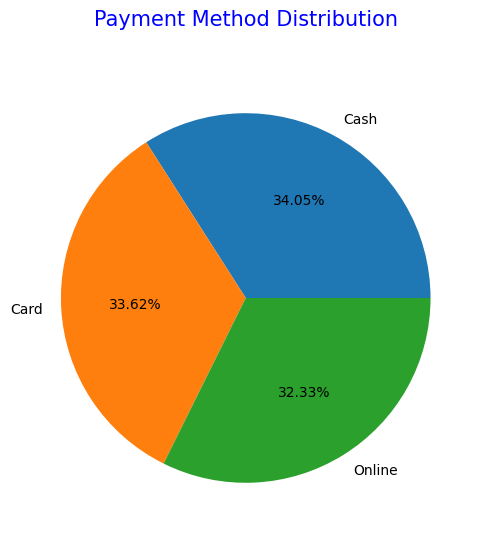

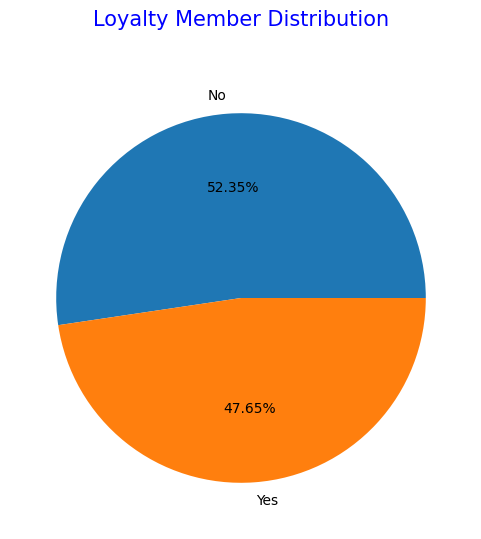

<Figure size 640x480 with 0 Axes>

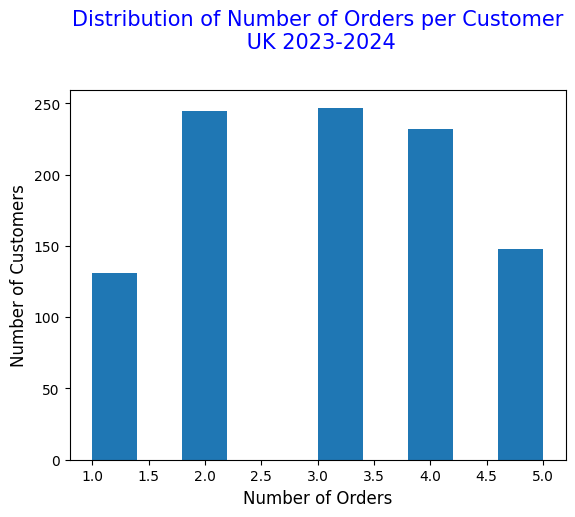

In [ ]:
# Create a pie chart of distribution of cities where the customers come from
merged_df['gmv'] = merged_df['quantity'] * merged_df['price']
gmv_per_city_uk = merged_df.groupby('city')['gmv'].sum().reset_index()
plt.figure(figsize=(6,6))
plt.pie(gmv_per_city_uk['gmv'], labels = gmv_per_city_uk['city'], autopct='%1.2f%%')
plt.title('GMV Contribution Per City - UK in 2023 - 2024', loc='center', pad=30, fontsize=15, color='blue')
plt.show()

# Create a pie chart of distribution of payment methods
payment_method_counts = merged_df['payment_method'].value_counts().reset_index()
payment_method_counts.columns = ['payment_method', 'count'] # Rename columns for clarity
plt.figure(figsize=(6,6))
plt.pie(payment_method_counts['count'], labels = payment_method_counts['payment_method'], autopct='%1.2f%%')
plt.title('Payment Method Distribution', loc='center', pad=30, fontsize=15, color='blue')
plt.show()

# Create a pie chart of distribution of loyalty member
loyalty_member_counts = merged_df['loyalty_member'].value_counts().reset_index()
loyalty_member_counts.columns = ['loyalty_member', 'count'] # Rename columns for clarity
plt.figure(figsize=(6,6))
plt.pie(loyalty_member_counts['count'], labels = loyalty_member_counts['loyalty_member'], autopct='%1.2f%%')
plt.title('Loyalty Member Distribution', loc='center', pad=30, fontsize=15, color='blue')
plt.show()


# Create a histogram for the distribution of number of orders per customer
data_per_customer = (merged_df.groupby('customer_id')
                                   .agg({'order_id':'nunique',
                                         'quantity': 'sum',
                                         'gmv':'sum'})
                                   .reset_index()
                                   .rename(columns={'order_id':'orders'}))

plt.clf()
plt.figure()
plt.hist(data_per_customer['orders'], range=(1,5))
plt.title('Distribution of Number of Orders per Customer\n UK 2023-2024', pad=30, fontsize=15, color='blue')
plt.xlabel('Number of Orders', fontsize = 12)
plt.ylabel('Number of Customers', fontsize = 12)
plt.show()

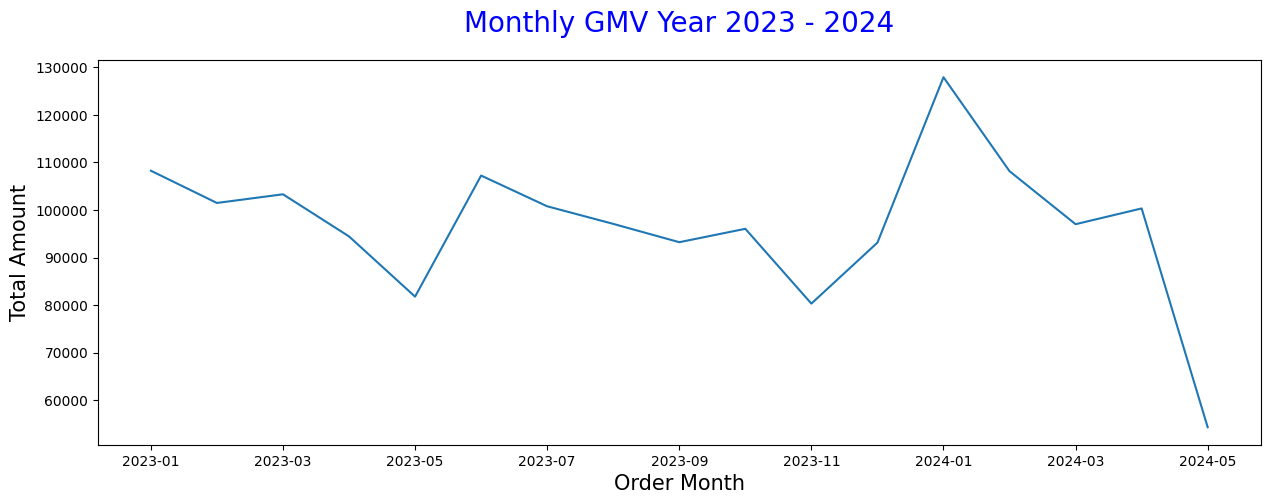

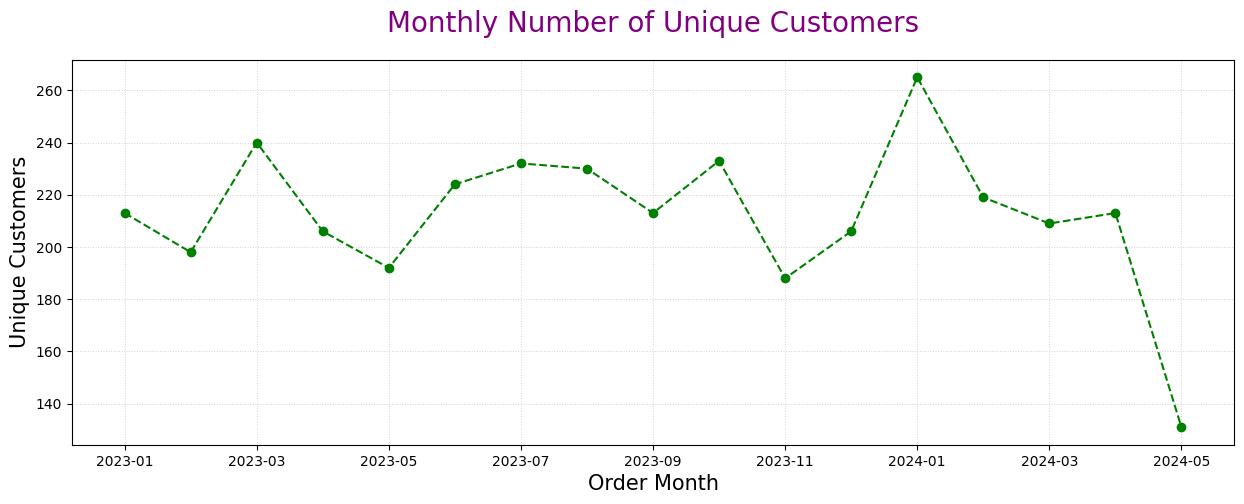

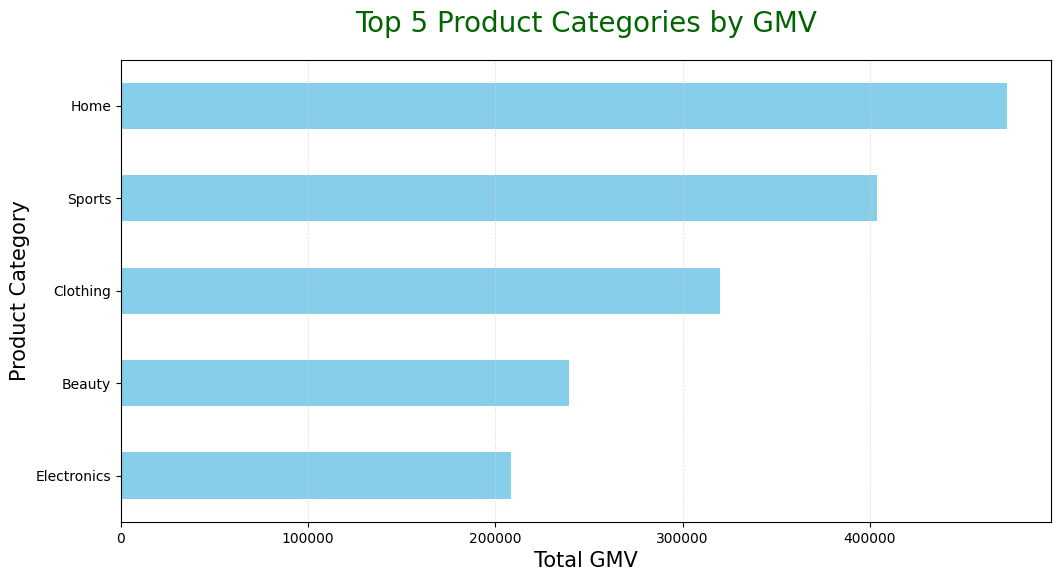

In [ ]:
# Buat kolom order_month
import datetime
merged_df['order_date'] = pd.to_datetime(merged_df['order_date']) # Ensure order_date is datetime
merged_df['order_month'] = merged_df['order_date'].dt.strftime('%Y-%m')
# Buat kolom gmv
merged_df['gmv'] = merged_df['quantity'] * merged_df['price']

# Plot 1: Monthly GMV Year 2023
plt.figure(figsize=(15, 5))
merged_df.groupby(['order_month'])['gmv'].sum().plot()
plt.title('Monthly GMV Year 2023 - 2024', loc='center', pad=20, fontsize=20, color='blue')
plt.xlabel('Order Month', fontsize=15)
plt.ylabel('Total Amount', fontsize=15)
plt.show()

# Plot 2: Monthly Number of Unique Customers
plt.figure(figsize=(15, 5))
merged_df.groupby('order_month')['customer_id'].nunique().plot(color='green', marker='o', linestyle='--')
plt.title('Monthly Number of Unique Customers', loc='center', pad=20, fontsize=20, color='purple')
plt.xlabel('Order Month', fontsize=15)
plt.ylabel('Unique Customers', fontsize=15)
plt.grid(color='lightgray', linestyle=':', linewidth=0.7)
plt.show()

# Plot 3: Top 5 Product Categories by GMV
plt.figure(figsize=(12, 6))
top_categories_gmv = merged_df.groupby('category')['gmv'].sum().nlargest(5)
top_categories_gmv.plot(kind='barh', color='skyblue')
plt.title('Top 5 Product Categories by GMV', loc='center', pad=20, fontsize=20, color='darkgreen')
plt.xlabel('Total GMV', fontsize=15)
plt.ylabel('Product Category', fontsize=15)
plt.xticks(rotation=0)
plt.grid(axis='x', color='lightgray', linestyle=':', linewidth=0.7)
plt.gca().invert_yaxis() # To have the highest value on top
plt.show()

<Figure size 1500x500 with 0 Axes>

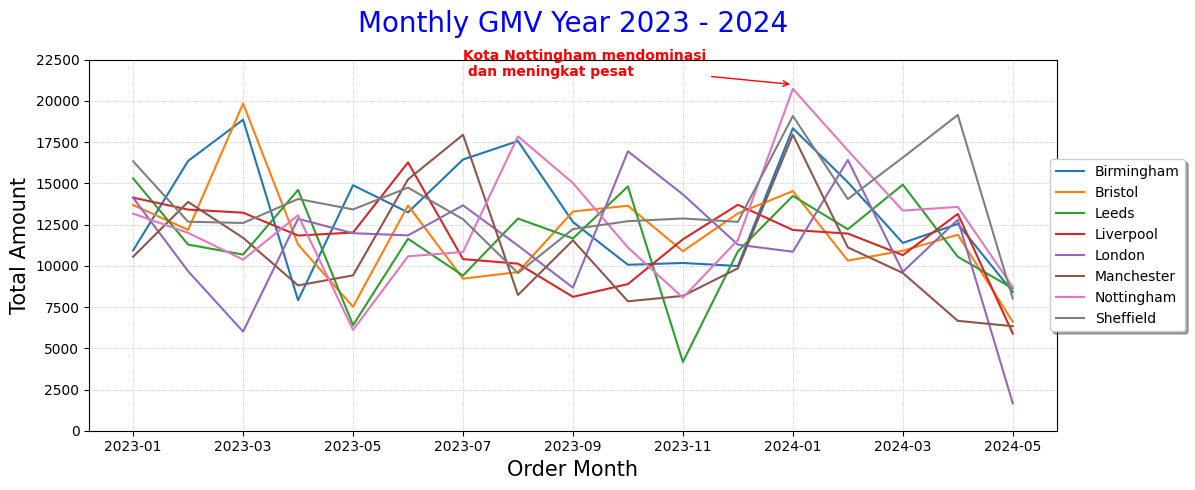

In [ ]:
# Plot 4: Monthly GMV Year 2023 - 2024
plt.figure(figsize=(15, 5))
merged_df.groupby(['order_month', 'city'])['gmv'].sum().unstack().plot()
plt.title('Monthly GMV Year 2023 - 2024', loc='center', pad=20, fontsize=20, color='blue')
plt.xlabel('Order Month', fontsize=15)
plt.ylabel('Total Amount', fontsize=15)
plt.grid(color='darkgray', linestyle=':', linewidth=0.5)
plt.ylim(ymin=0)
labels, locations = plt.yticks()
plt.yticks(labels)
plt.legend(loc='right', bbox_to_anchor=(1.14, 0.5), shadow=True, ncol=1)

plt.annotate('Kota Nottingham mendominasi\n dan meningkat pesat', xy=(12, 21000), xytext=(6, 21500),
             weight='bold', color='red',
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='red'))
plt.gcf().set_size_inches(12, 5)
plt.tight_layout()
plt.show()
plt.show()

In [ ]:
# Find customers with the highest spend
data_per_customer = (merged_df.groupby('customer_id')
                                   .agg({'order_id':'nunique',
                                         'quantity': 'sum',
                                         'gmv':'sum'})
                                   .reset_index()
                                   .rename(columns={'order_id':'orders'}))
print(data_per_customer.sort_values(by='gmv', ascending=False))

    customer_id  orders  quantity      gmv
289       C0299       8        28  5124.21
89        C0094       8        24  5078.51
568       C0588       9        27  4874.30
790       C0826       7        25  4685.22
323       C0334       8        30  4515.14
..          ...     ...       ...      ...
105       C0111       1         1    41.44
414       C0428       1         3    40.32
693       C0724       1         1    36.66
181       C0191       1         3    33.21
778       C0813       1         3    33.21

[1149 rows x 4 columns]


In [ ]:
# Find average spend per customers
data_per_customer = (merged_df.groupby('customer_id')
                                   .agg({'order_id':'nunique',
                                         'quantity': 'sum',
                                         'gmv':'sum'})
                                   .reset_index()
                                   .rename(columns={'order_id':'orders'}))
print(data_per_customer['gmv'].mean())

1431.5210704960834
